(7,)
i    5
j    6
dtype: int64


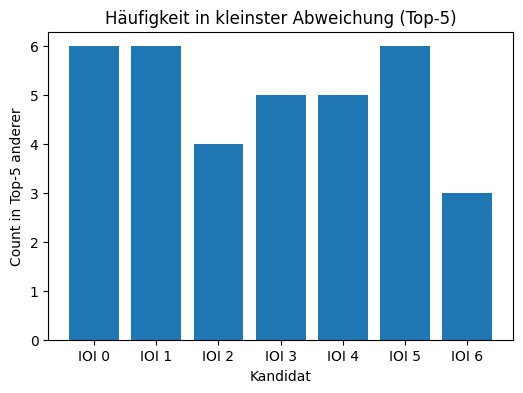

    index    ioi  K_int  base_candidate  pair_with     ratio  proximity  \
0       0  2.006      1           2.006          1  1.006523   0.995987   
1       0  2.006      1           2.006          3  1.034554   0.905314   
2       0  2.006      1           2.006          5  1.066800   0.688619   
3       0  2.006      1           2.006          2  1.075027   0.623512   
4       0  2.006      1           2.006          4  1.124128   0.262996   
5       1  1.993      1           1.993          0  1.006523   0.995987   
6       1  1.993      1           1.993          3  1.027849   0.937151   
7       1  1.993      1           1.993          2  1.068060   0.678763   
8       1  1.993      1           1.993          5  1.073758   0.633647   
9       1  1.993      1           1.993          4  1.131460   0.221568   
10      2  1.866      1           1.866          3  1.039121   0.880443   
11      2  1.866      1           1.866          1  1.068060   0.678763   
12      2  1.866      1  

In [104]:
# === 0) new Initialisierung ===

# ===============================================
# Analyse von IOI-Verhältnissen zur Beat-Detektion 
# ===============================================

# =============================
# 0) Imports
# =============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.integrate import simpson
from scipy.signal import argrelextrema
from fractions import Fraction
from collections import Counter
from functools import reduce
from math import gcd

# =============================
# 1) Proximity-Funktion
# =============================
def proximity_max_freq(
    x,
    sharpness_base=1.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    freqs = np.arange(1, max_freq + 1)
    all_freq_values = []

    for freq in freqs:
        weight = 1.0 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        peak_value = np.where(peak_value == 0, 1e-12, peak_value)

        denom = np.where(x == 0, 1e-12, x ** decay)
        val = weight * (cos_term / peak_value) / denom
        all_freq_values.append(val)

    all_freq_values = np.array(all_freq_values)
    peak_indices = np.argmax(all_freq_values, axis=0)
    proximity_max = np.max(all_freq_values, axis=0)

    max_at_norm_x = np.max([
        (1.0 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in freqs
    ])
    proximity_max = proximity_max / max_at_norm_x * output_max
    return proximity_max, peak_indices, freqs

# =============================
# 2) Funktion für IOI-Paare
# =============================
def build_pairwise_proximity_df(iois, params, threshold=0.01):
    n = len(iois)
    ratios = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j]) 
                        for j in range(n)] for i in range(n)])
    prox_max, peak_idx, freqs = proximity_max_freq(ratios, **params)

    rows = []
    for i in range(n):
        for j in range(i + 1, n):
            r = float(ratios[i, j])
            s = float(prox_max[i, j])
            if s > threshold:
                best_f = int(freqs[peak_idx[i, j]])
                p = int(round(r * best_f))
                frac = Fraction(p, best_f)
                label = f"{frac.numerator}/{frac.denominator}"
            else:
                label = "Keine Proximity"

            rows.append({
                "i": i,
                "j": j,
                "ioi_i": float(iois[i]),
                "ioi_j": float(iois[j]),
                "ratio": r,
                "proximity": s,
                "peak_label": label
            })

    df_pairs = pd.DataFrame(rows)
    return df_pairs, ratios, prox_max

# =============================
# 3) Basis-IOI aus Paaren bestimmen (LCM-Methode)
# =============================
def best_fit_ioi_from_pairs(iois, df_pairs, threshold):
    valid_pairs = df_pairs[df_pairs["proximity"] > threshold]
    fractions_list = []
    for label in valid_pairs["peak_label"]:
        if label != "Keine Proximity":
            num, den = map(int, label.split("/"))
            fractions_list.append(Fraction(num, den))

    if not fractions_list:
        return None

    denominators = [frac.denominator for frac in fractions_list]
    lcm_den = np.lcm.reduce(denominators)

    # Vielfachfaktor pro IOI bestimmen
    k_values = [None] * len(iois)
    for idx in range(len(iois)):
        factors = []
        for _, row in valid_pairs.iterrows():
            if row["peak_label"] == "Keine Proximity":
                continue
            num, den = map(int, row["peak_label"].split("/"))
            frac = Fraction(num, den)
            num_scaled = frac.numerator * (lcm_den // frac.denominator)
            if row["i"] == idx:
                factors.append(num_scaled)
            elif row["j"] == idx:
                factors.append(num_scaled)
        if factors:
            k_values[idx] = min(factors)

    if any(k is None for k in k_values):
        print("Warnung: Nicht für alle IOIs ein Faktor gefunden.")
        return None

    base_ioi = np.mean([iois[i] / k_values[i] for i in range(len(iois))])
    return base_ioi

# =============================
# 4) Parameter, Daten laden & Pairs bauen
# =============================
params = dict(
    sharpness_base=8.0,
    sharpness_growth=0.5,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
)
PAIR_THRESHOLD = 0.01

filename = "KWA6.csv"
base_dir = Path("../data/Kwa-Sounds Scorpaena spp./")
seq_path = base_dir / filename
if not seq_path.exists():
    raise FileNotFoundError(f"Datei nicht gefunden: {seq_path.resolve()}")

df = pd.read_csv(seq_path)

# Nur gültige IOIs verwenden
iois = df["IOI"].dropna().values
onsets = df["onset"].dropna().values

# Pairs sofort neu berechnen – kein alter Cache!
df_pairs, ratios, prox_max = build_pairwise_proximity_df(iois, params, threshold=PAIR_THRESHOLD)

# =============================
# compute_ioi_positions_fixed – jetzt mit Auto-Check
# =============================
def compute_ioi_positions_fixed(iois, df_pairs, threshold=0.01, verbose=False):
    """
    Aus Paar-DF -> IOI-Positions-DF mit konsistenter Netzwerk-Skalierung.
    Immer 5 Zeilen pro IOI (mit evtl. 0-Abweichung).
    Außerdem am Ende: Barplot mit Counts pro Kandidat.
    """

    # --- Sicherheitscheck ---
    max_index_in_pairs = max(df_pairs["i"].max(), df_pairs["j"].max())
    if max_index_in_pairs >= len(iois):
        print("⚠️ df_pairs passt nicht zu iois – baue neu...")
        df_pairs, _, _ = build_pairwise_proximity_df(iois, params, threshold=threshold)

    n = len(iois)

    # --- 1) Kantenliste ---
    edges = []
    for r in df_pairs.itertuples():
        if getattr(r, "proximity", 0) <= threshold:
            continue
        label = getattr(r, "peak_label", "")
        if not label or label == "Keine Proximity":
            continue
        try:
            p, q = map(int, label.split("/"))
        except Exception:
            continue
        if r.ioi_i >= r.ioi_j:
            u, v, frac = int(r.i), int(r.j), Fraction(p, q)
        else:
            u, v, frac = int(r.j), int(r.i), Fraction(p, q)
        edges.append((u, v, frac))

    # --- 2) BFS / Propagation ---
    K_rel = [None] * n
    seed = int(np.argmax(iois))
    K_rel[seed] = Fraction(1, 1)
    changed = True
    for _ in range(10 * n):
        if not changed:
            break
        changed = False
        for u, v, frac in edges:
            if K_rel[u] is not None and K_rel[v] is None:
                K_rel[v] = K_rel[u] * Fraction(frac.denominator, frac.numerator)
                changed = True
            elif K_rel[v] is not None and K_rel[u] is None:
                K_rel[u] = K_rel[v] * frac
                changed = True
    for idx, val in enumerate(K_rel):
        if val is None:
            K_rel[idx] = Fraction(1, 1)

    # --- 3) Basistakt ---
    K_rel_float = np.array([float(k) for k in K_rel])
    base_candidates = np.array(iois) / K_rel_float
    t0 = float(np.median(base_candidates))
    if t0 <= 0:
        raise RuntimeError("Ungültiger t0")

    # --- 4) Ganzzahlige K_int ---
    K_int = np.rint(np.array(iois) / t0).astype(int)
    K_int[K_int < 1] = 1
    g = int(reduce(gcd, K_int.tolist()))
    if g > 1:
        K_int //= g

    # --- 5) DataFrame (Top-5 Paare) ---
    rows = []
    for i in range(n):
        pairs_i = df_pairs[(df_pairs["i"] == i) | (df_pairs["j"] == i)]
        pairs_i = pairs_i.sort_values(by="proximity", ascending=False)
        while len(pairs_i) < 5:
            pairs_i = pd.concat([pairs_i, pd.DataFrame([{
                "i": i, "j": None, "ioi_i": iois[i], "ioi_j": None,
                "ratio": None, "proximity": 0.0, "peak_label": "Keine Abweichung"
            }])], ignore_index=True)
        top5 = pairs_i.head(5)
        for _, r in top5.iterrows():
            rows.append({
                "index": i,
                "ioi": iois[i],
                "K_int": int(K_int[i]),
                "base_candidate": float(iois[i] / K_int[i]),
                "pair_with": r["j"] if r["i"] == i else r["i"],
                "ratio": r["ratio"],
                "proximity": r["proximity"],
                "peak_label": r["peak_label"]
            })

    df_ioi_positions = pd.DataFrame(rows)

    # --- 6) Barplot ---
    counts = df_ioi_positions["pair_with"].value_counts().sort_index()
    plt.figure(figsize=(6, 4))
    plt.bar(range(len(counts)), counts.values, tick_label=[f"IOI {i}" for i in counts.index])
    plt.xlabel("Kandidat")
    plt.ylabel("Count in Top-5 anderer")
    plt.title("Häufigkeit in kleinster Abweichung (Top-5)")
    plt.show()

    if verbose:
        print("t0:", t0)
        print("K_int:", K_int.tolist())

    return df_ioi_positions, t0

# =============================
# Anwendung auf Daten
# =============================
print(iois.shape)
print(df_pairs[['i', 'j']].max())

df_ioi_positions, t0 = compute_ioi_positions_fixed(iois, df_pairs, threshold=PAIR_THRESHOLD)

if df_ioi_positions is not None:
    print(df_ioi_positions)
    print("\nGemittelter Basis-IOI:", df_ioi_positions["base_candidate"].mean())
else:
    print("Keine gültigen Verhältnisse gefunden.")


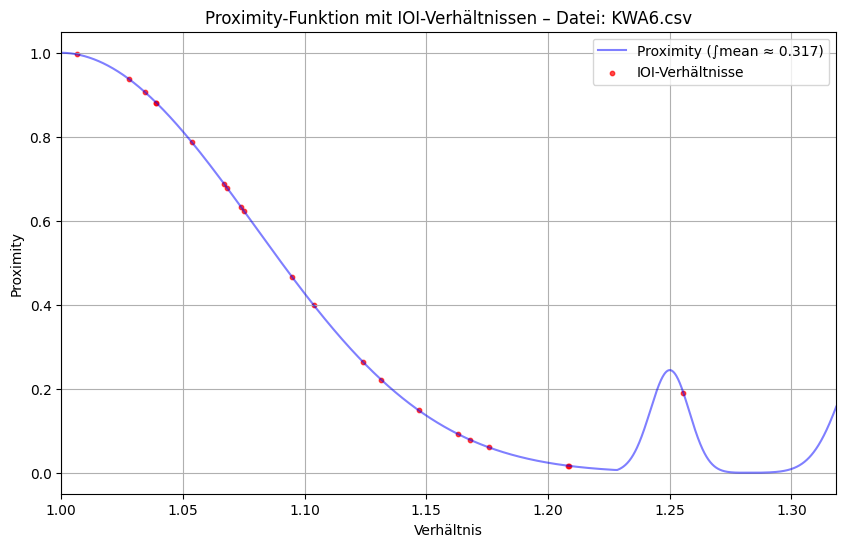

In [106]:
# === 1) Proximity-Funktion + Punkte ===
plt.figure(figsize=(10, 6))

# Dynamische Grenzen aus den Daten bestimmen
x_min = max(1.0, df_pairs["ratio"].min() * 0.95)  # kleiner Puffer nach unten
x_max = df_pairs["ratio"].max() * 1.05            # Puffer nach oben

# Blaue Kurve über den ganzen Plotbereich
x_range = np.linspace(x_min, x_max, 2000)
y_curve = np.array([proximity_max_freq(x, **params)[0] for x in x_range])

# Mittelwert für diesen Bereich
mean_prox = simpson(y_curve, x=x_range) / (x_range[-1] - x_range[0])

# Plotten
plt.plot(
    x_range,
    y_curve,
    label=f"Proximity (∫mean ≈ {mean_prox:.3f})",
    alpha=0.5,
    color="blue"
)
plt.scatter(df_pairs["ratio"].values, df_pairs["proximity"].values, 
            s=10, alpha=0.7, color="red", label="IOI-Verhältnisse")

plt.title(f"Proximity-Funktion mit IOI-Verhältnissen – Datei: {filename}")
plt.xlabel("Verhältnis")
plt.ylabel("Proximity")
plt.xlim(x_min, x_max)
plt.legend()
plt.grid(True)
plt.show()


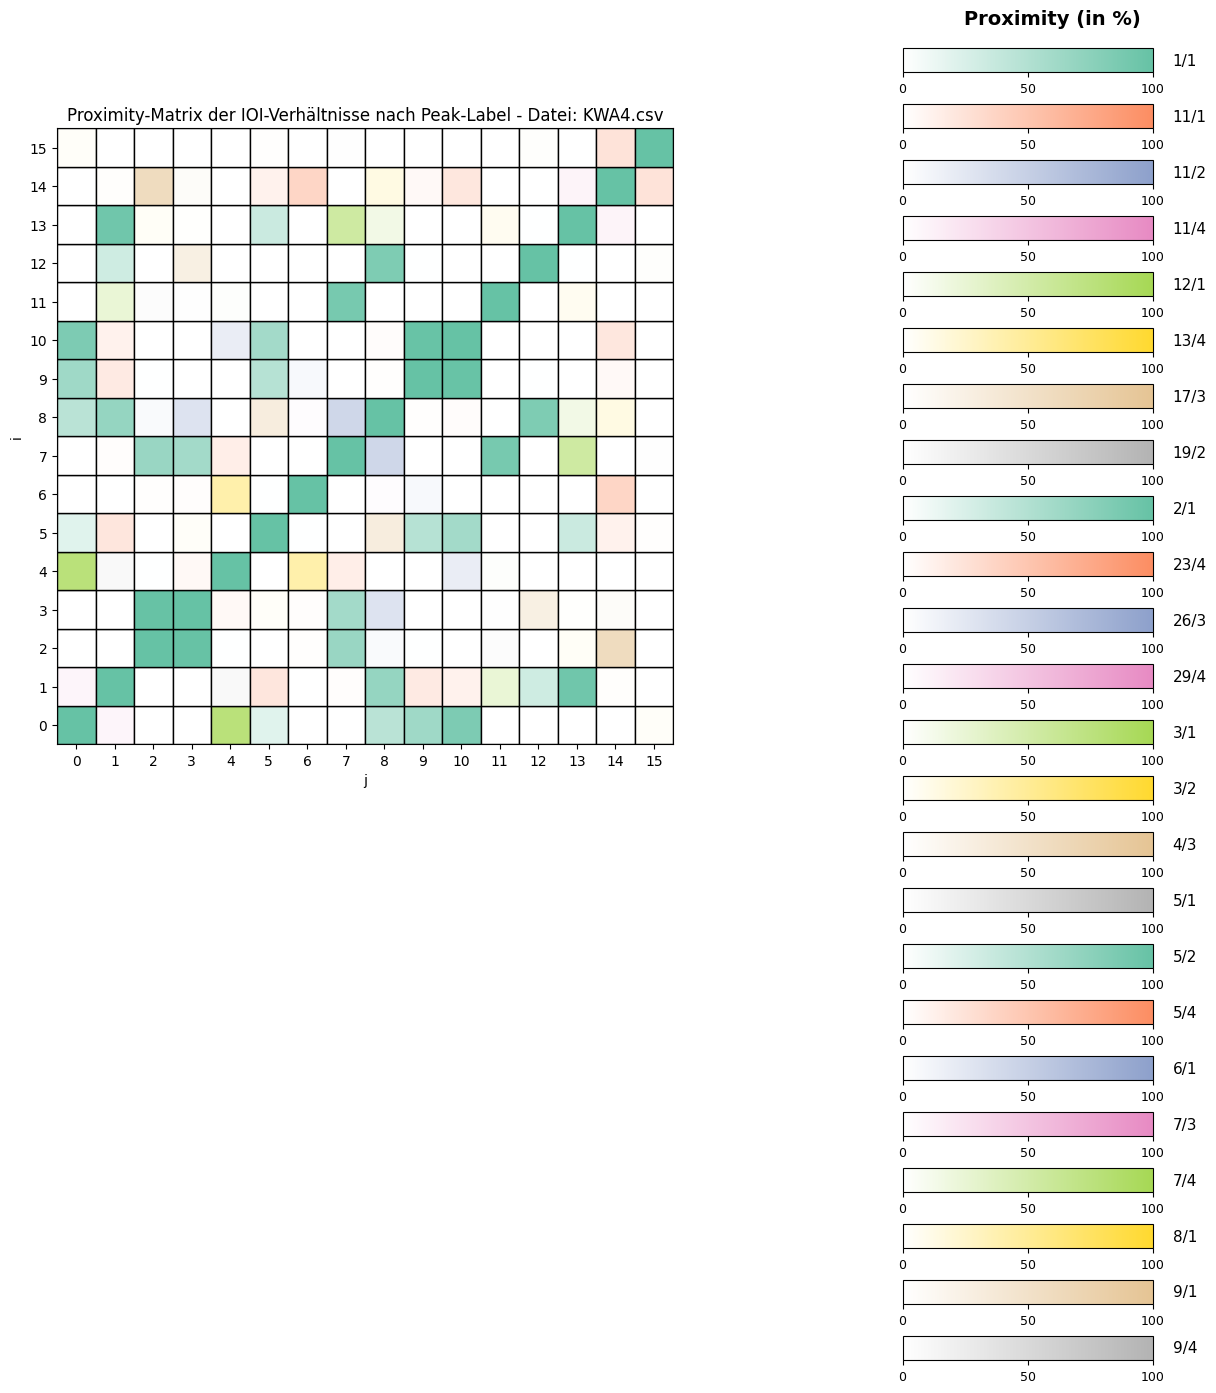

In [86]:
# === 2) Recurrence-Plot (Peak-Label-Farbskalen) ===

# === all_pairs_df erstellen ===
records = []
n = len(iois)
for i in range(n):
    for j in range(n):
        ratio = max(iois[i], iois[j]) / min(iois[i], iois[j])
        prox_val = proximity_max_freq([ratio], **params)[0]
        if prox_val > PAIR_THRESHOLD:
            frac = Fraction(ratio).limit_denominator(params["max_freq"])
            peak_label = f"{frac.numerator}/{frac.denominator}"
        else:
            peak_label = "Keine Proximity"
        records.append({
            "i": i,
            "j": j,
            "ioi_i": iois[i],
            "ioi_j": iois[j],
            "ratio": ratio,
            "prox_value": prox_val,
            "peak_label": peak_label
        })
all_pairs_df = pd.DataFrame.from_records(records)

# === Plot vorbereiten ===
pivot_vals = all_pairs_df.pivot(index="i", columns="j", values="prox_value") * 100
pivot_labels = all_pairs_df.pivot(index="i", columns="j", values="peak_label")

unique_labels = sorted(set(all_pairs_df["peak_label"]))
palette = sns.color_palette("Set2", len(unique_labels))
label_to_cmap = {}
for label, base_color in zip(unique_labels, palette):
    white_rgb = (1, 1, 1)
    cmap_colors = [white_rgb, base_color]
    label_to_cmap[label] = plt.cm.colors.LinearSegmentedColormap.from_list(f"{label}_cmap", cmap_colors)

# === Plot zeichnen ===
fig, ax = plt.subplots(figsize=(10, 8))
for (i, j), val in np.ndenumerate(pivot_vals.values):
    label = pivot_labels.iloc[i, j]
    cmap = label_to_cmap[label]
    color = cmap(val / 100)  # Wert zwischen 0 und 1
    rect = plt.Rectangle([j, i], 1, 1, facecolor=color, edgecolor='black')
    ax.add_patch(rect)
    val_float = float(val[0])     # explizit erstes Element wählen # von ndarray zu Skalar
    #ax.text(j + 0.5, i + 0.5, f"{int(round(val_float))}", ha='center', va='center', fontsize=8) # ausschalten, wenn lange sequenz

# Achsen von 0 aufsteigend
ax.set_xlim(0, n)
ax.set_ylim(0, n)
ax.set_aspect('equal')
ax.set_xticks(np.arange(n) + 0.5)
ax.set_yticks(np.arange(n) + 0.5)
ax.set_xticklabels(range(n))
ax.set_yticklabels(range(n))
ax.set_xlabel("j")
ax.set_ylabel("i")
ax.set_title(f"Proximity-Matrix der IOI-Verhältnisse nach Peak-Label - Datei: {filename}")

# Nur Verhältnisse mit Proximity > 0 anzeigen
legend_labels = [lab for lab in unique_labels if lab != "Keine Proximity"]

# Position für die Legende rechts neben dem Plot
legend_x_start = 1.05
legend_y_start = 0.95
cbar_height = 0.03
spacing = 0.04

# Überschrift für alle Skalen
fig.text(legend_x_start + 0.15, legend_y_start + 0.06, "Proximity (in %)", 
         ha="center", fontsize=14, fontweight="bold")

for idx, label in enumerate(legend_labels):
    cmap = label_to_cmap[label]
    norm = plt.Normalize(vmin=0, vmax=100)

    y_pos = legend_y_start - idx * (cbar_height + spacing)

    # Größerer horizontaler Farbbalken
    cbar_ax = fig.add_axes([legend_x_start, y_pos, 0.25, cbar_height])  
    cb = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
                      cax=cbar_ax, orientation="horizontal")
    cb.set_ticks([0, 50, 100])
    cb.ax.tick_params(labelsize=9)

    # Verhältnis rechts vom Balken
    fig.text(legend_x_start + 0.27, y_pos + cbar_height / 2, label,
             va="center", fontsize=11)

plt.show()

Max IOI: 2.343, Mean IOI: 2.077428571428572, Sequence Length: 7


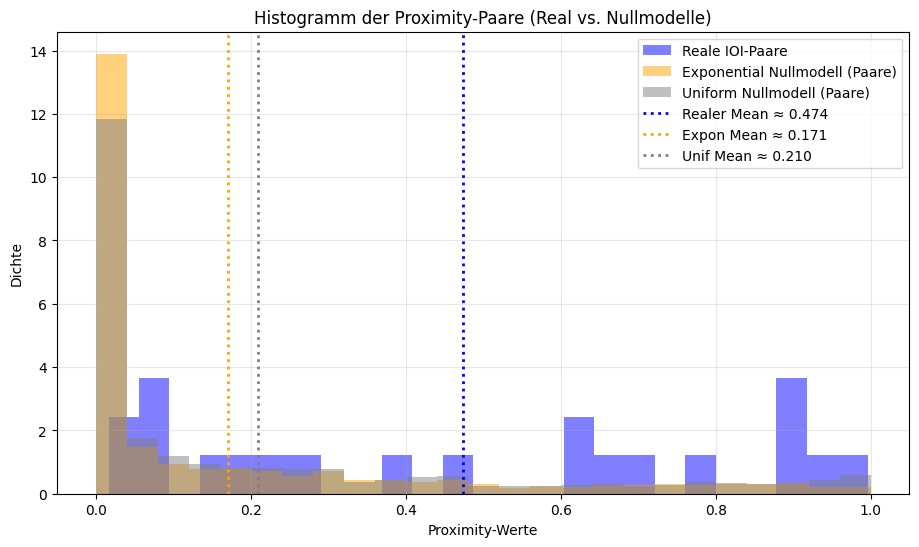


=== Ergebnisse ===
real_mean: 0.4745
expon_mean: 0.1708
expon_std: 0.2643
uniform_mean: 0.2096
uniform_std: 0.2894
diff_real_expon_mean: 0.3037
diff_real_uniform_mean: 0.2649


In [102]:
# newwwer === 3) Kombiniertes Histogramm mit Anteilen + 95%-Quantil ===
def plot_proximity_pairs(iois, params, num_sequences=1000, seed=4, bins=25):
    """
    Vergleicht Proximity-Paare der realen Sequenz mit Nullmodellen (Uniform & Exponential)
    und berechnet Mittelwerte, Standardabweichungen und Differenzen.
    """
    rng = np.random.default_rng(seed)

    sequence_length = len(iois)
    max_ioi = float(np.max(iois))
    mean_ioi = float(np.mean(iois))
    print(f"Max IOI: {max_ioi}, Mean IOI: {mean_ioi}, Sequence Length: {sequence_length}")

    # ================================
    # Reale Proximity-Paare
    # ================================
    ratios_real = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j]) 
                             for j in range(sequence_length)] for i in range(sequence_length)])
    prox_mat_real, _, _ = proximity_max_freq(ratios_real, **params)
    triu_idx = np.triu_indices_from(prox_mat_real, k=1)
    proximity_real = prox_mat_real[triu_idx]
    mean_real = np.mean(proximity_real)

    # ================================
    # Nullmodell: Exponential (alle Paare)
    # ================================
    proximity_expon_all = []
    for seq_idx in range(num_sequences):
        pois_iois = rng.exponential(scale=mean_ioi, size=sequence_length)
        ratios = np.array([[max(pois_iois[i], pois_iois[j]) / min(pois_iois[i], pois_iois[j]) 
                            for j in range(sequence_length)] for i in range(sequence_length)])
        prox_mat, _, _ = proximity_max_freq(ratios, **params)
        proximity_expon_all.append(prox_mat[triu_idx])
    proximity_expon_all = np.concatenate(proximity_expon_all)
    mean_expon = np.mean(proximity_expon_all)
    std_expon  = np.std(proximity_expon_all)

    # ================================
    # Nullmodell: Uniform (alle Paare)
    # ================================
    proximity_uniform_all = []
    for seq_idx in range(num_sequences):
        unif_iois = rng.uniform(0.01, max_ioi, size=sequence_length)
        ratios = np.array([[max(unif_iois[i], unif_iois[j]) / min(unif_iois[i], unif_iois[j]) 
                            for j in range(sequence_length)] for i in range(sequence_length)])
        prox_mat, _, _ = proximity_max_freq(ratios, **params)
        proximity_uniform_all.append(prox_mat[triu_idx])
    proximity_uniform_all = np.concatenate(proximity_uniform_all)
    mean_uniform = np.mean(proximity_uniform_all)
    std_uniform  = np.std(proximity_uniform_all)

    # ================================
    # Plot
    # ================================
    plt.figure(figsize=(11, 6))
    plt.hist(proximity_real,        bins=bins, color='blue',   density=True, alpha=0.5, label="Reale IOI-Paare")
    plt.hist(proximity_expon_all,   bins=bins, color='orange', density=True, alpha=0.5, label="Exponential Nullmodell (Paare)")
    plt.hist(proximity_uniform_all, bins=bins, color='gray',   density=True, alpha=0.5, label="Uniform Nullmodell (Paare)")

    plt.axvline(mean_real,    color='blue',   linestyle=':', linewidth=2, label=f"Realer Mean ≈ {mean_real:.3f}")
    plt.axvline(mean_expon,   color='orange', linestyle=':', linewidth=2, label=f"Expon Mean ≈ {mean_expon:.3f}")
    plt.axvline(mean_uniform, color='gray',   linestyle=':', linewidth=2, label=f"Unif Mean ≈ {mean_uniform:.3f}")

    plt.xlabel("Proximity-Werte")
    plt.ylabel("Dichte")
    plt.title("Histogramm der Proximity-Paare (Real vs. Nullmodelle)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # ================================
    # Ergebnisse berechnen
    # ================================
    results = {
        "real_mean": mean_real,
        "expon_mean": mean_expon,
        "expon_std": std_expon,
        "uniform_mean": mean_uniform,
        "uniform_std": std_uniform,
        "diff_real_expon_mean": mean_real - mean_expon,
        "diff_real_uniform_mean": mean_real - mean_uniform,
    }

    print("\n=== Ergebnisse ===")
    for k, v in results.items():
        print(f"{k}: {v:.4f}")

    return {
        "proximity_real": proximity_real,
        "proximity_expon_all": proximity_expon_all,
        "proximity_uniform_all": proximity_uniform_all,
        "results": results
    }

# === Anwendung ===
results_pairs = plot_proximity_pairs(iois, params, num_sequences=200, seed=42)


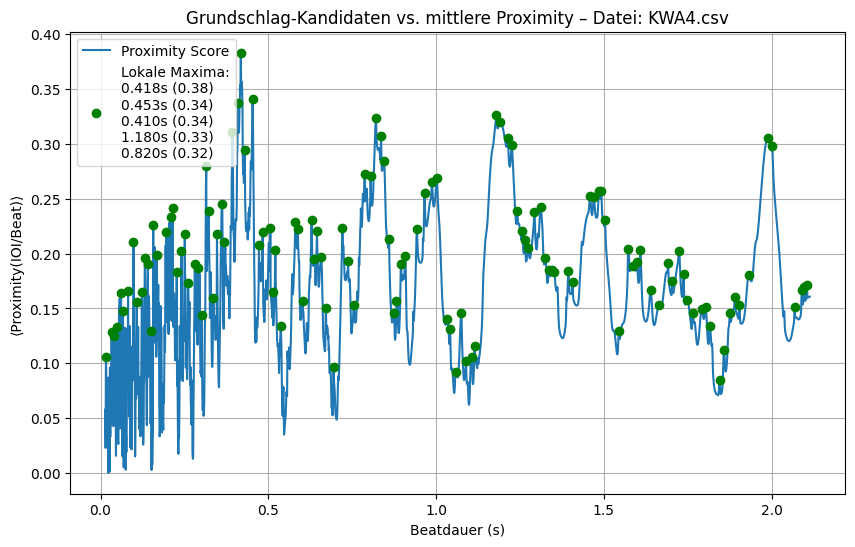

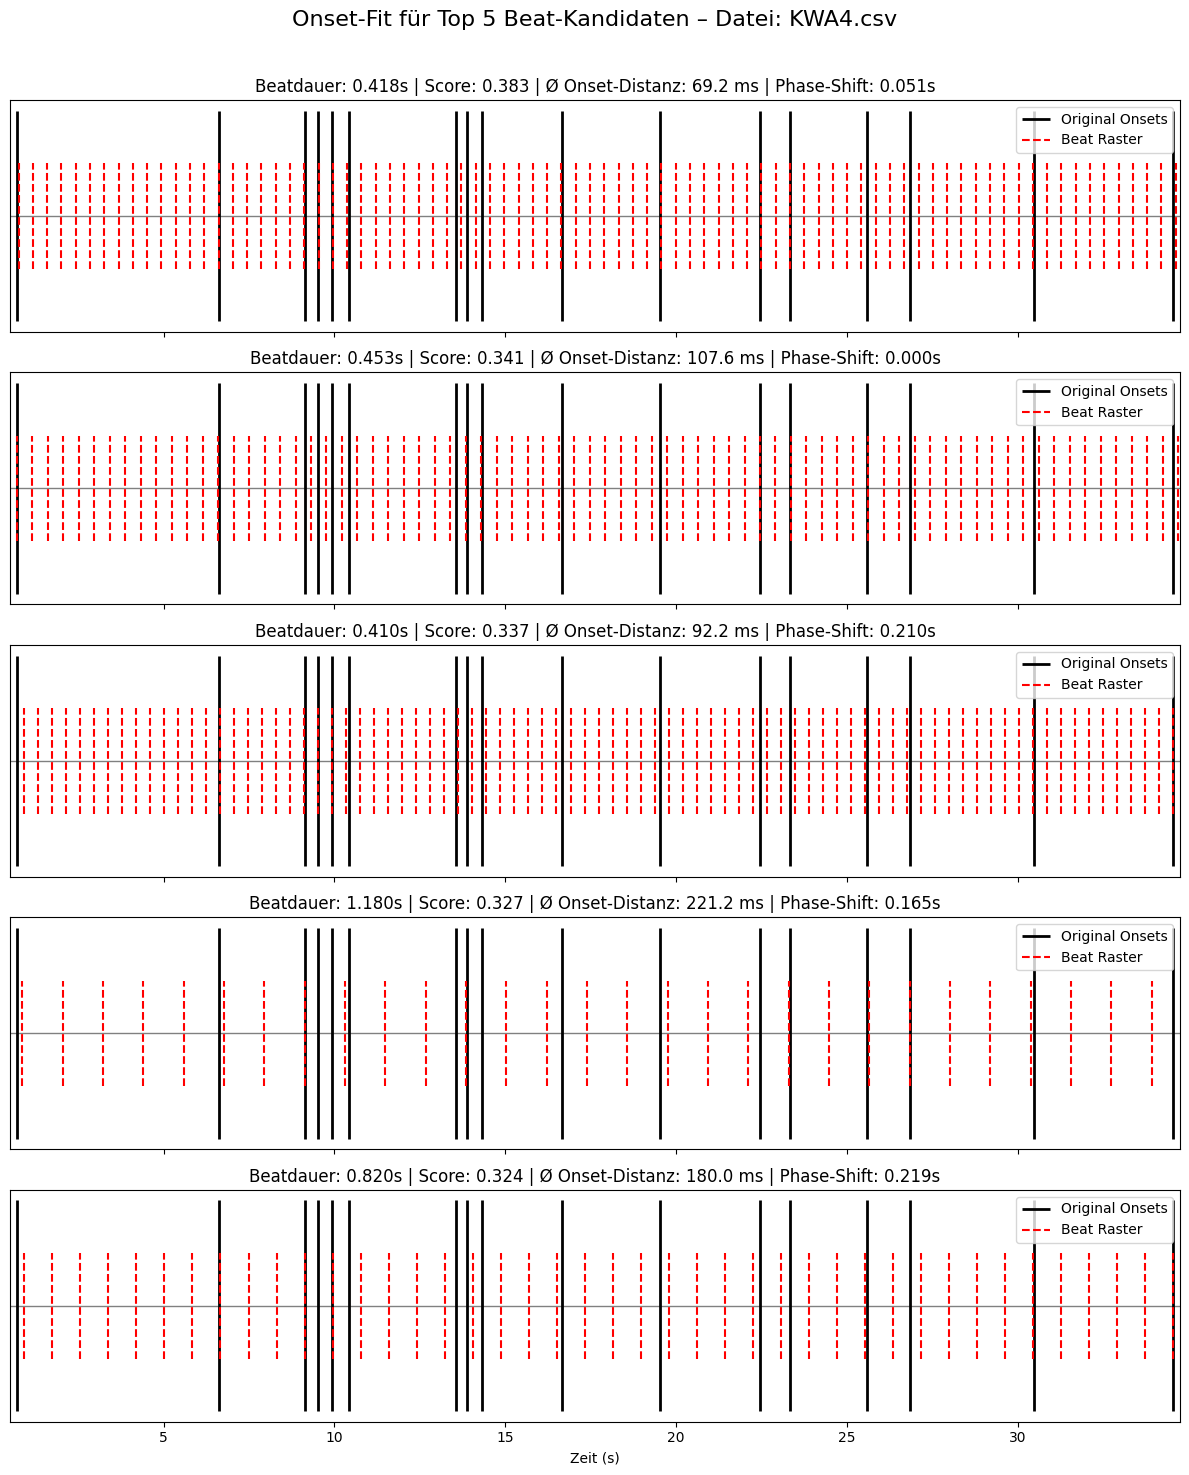

In [84]:
# === 4) Beatfinding via Kandidaten und lokalen Maxima ===

# =============================
# 2) Hilfsfunktionen
# =============================
def round_to_resolution(x, resolution):
    return round(x / resolution) * resolution

def generate_beat_candidates_from_iois(iois, resolution=0.001, max_denominator=24):
    if len(iois) == 0:
        return []

    max_ioi = float(np.max(iois))
    min_ioi = float(np.min(iois)) / max_denominator  # dynamisches min_ioi

    raster = np.arange(min_ioi, max_ioi + resolution/2, resolution)
    candidates = set(round_to_resolution(val, resolution) for val in raster)

    for ioi in iois:
        if ioi < min_ioi or ioi > max_ioi:
            continue
        for denom in range(1, max_denominator + 1):
            beat = ioi / denom
            if min_ioi <= beat <= max_ioi:
                candidates.add(round_to_resolution(beat, resolution))

    for denom in range(1, max_denominator + 1):
        val = 1.0 / denom
        if min_ioi <= val <= max_ioi:
            candidates.add(round_to_resolution(val, resolution))

    # === Filter: Kandidaten müssen mindestens so viele Beats abdecken wie IOIs existieren ===
    duration = float(np.sum(iois))
    n_iois = len(iois)
    filtered_candidates = []
    for beat in sorted(candidates):
        n_beats = int(duration // beat)
        if n_beats >= n_iois:
            filtered_candidates.append(beat)

    return filtered_candidates

def score_for_beat(beat, iois, params):
    ratios = np.maximum(iois, beat) / np.minimum(iois, beat)
    prox_vals, _, _ = proximity_max_freq(ratios, **params)
    return float(np.mean(prox_vals))

def find_local_maxima(candidates, scores, order=2):
    indices = argrelextrema(np.array(scores), np.greater, order=order)[0]
    return [(candidates[i], scores[i]) for i in indices]

# =============================
# 7) Beat-Kandidaten
# =============================
beat_candidates = generate_beat_candidates_from_iois(iois)
scores = [score_for_beat(beat, iois, params) for beat in beat_candidates]
local_maxima = find_local_maxima(beat_candidates, scores, order=5)
local_maxima_top5 = sorted(local_maxima, key=lambda x: -x[1])[:5]

# === 4) Beat-Kandidaten & Score ===
plt.figure(figsize=(10, 6))
plt.plot(beat_candidates, scores, label="Proximity Score")
for beat, score in local_maxima:
    plt.plot(beat, score, 'o', color='green')
top_labels = [f"{beat:.3f}s ({score:.2f})" for beat, score in local_maxima_top5]
plt.plot([], [], 'o', color='green', label="Lokale Maxima:\n" + "\n".join(top_labels))
plt.title(f"Grundschlag-Kandidaten vs. mittlere Proximity – Datei: {filename}")
plt.xlabel("Beatdauer (s)")
plt.ylabel("⟨Proximity(IOI/Beat)⟩")
plt.legend()
plt.grid(True)
plt.show()

# =============================
# 8) Top-5 Onset-Fit
# =============================
def find_best_phase_shift(onsets, beat_period, resolution=0.001):
    first_onset = onsets[0]
    last_onset = onsets[-1]
    search_range = np.arange(0, beat_period, resolution)
    best_shift = 0.0
    best_score = float('inf')
    for shift in search_range:
        beats = np.arange(first_onset + shift, last_onset + beat_period, beat_period)
        dists = np.min(np.abs(onsets[:, None] - beats[None, :]), axis=1)
        score = np.mean(dists)
        if score < best_score:
            best_score = score
            best_shift = float(shift)
    return best_shift

def match_beats_to_onsets(onsets, beat_period, phase_shift=0.0):
    first_onset = onsets[0]
    last_onset = onsets[-1]
    beat_times = np.arange(first_onset + phase_shift, last_onset + beat_period, beat_period)
    dists = np.min(np.abs(onsets[:, None] - beat_times[None, :]), axis=1)
    return {
        "beat_times": beat_times,
        "mean_onset_dist": float(np.mean(dists)),
        "std_onset_dist": float(np.std(dists))
    }

n_top = len(local_maxima_top5)
if n_top > 0:
    fig2, axes2 = plt.subplots(n_top, 1, figsize=(12, 3 * n_top), sharex=True)
    fig2.suptitle(f"Onset-Fit für Top {n_top} Beat-Kandidaten – Datei: {filename}", fontsize=16)
    if n_top == 1:
        axes2 = [axes2]
    for idx, (beat, score) in enumerate(local_maxima_top5):
        ax = axes2[idx]
        best_shift = find_best_phase_shift(onsets, beat)
        stats = match_beats_to_onsets(onsets, beat, phase_shift=best_shift)
        ax.axhline(0, color='gray', linewidth=1)
        ax.vlines(onsets, -0.2, 0.2, color='black', linewidth=2, label='Original Onsets')
        ax.vlines(stats["beat_times"], -0.1, 0.1, color='red', linestyle='--', label='Beat Raster')
        title = (
        f"Beatdauer: {beat:.3f}s | Score: {score:.3f} | "
        f"Ø Onset-Distanz: {stats['mean_onset_dist']*1000:.1f} ms | "
        f"Phase-Shift: {best_shift:.3f}s"
        )
        ax.set_title(title)
        ax.set_yticks([])
        ax.set_xlim(onsets[0] - 0.2, onsets[-1] + 0.2)
        ax.legend(loc='upper right')
    plt.xlabel("Zeit (s)")
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()
else:
    print("\nKeine lokalen Maxima gefunden — überspringe Onset-Fit Visualisierung.")